In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")


In [2]:
# Notebook lives in outputs/
PROJECT_ROOT = Path("..").resolve()

BASELINE_DIR = PROJECT_ROOT / "outputs" / "baseline"
DQN_DIR = PROJECT_ROOT / "outputs" / "dqn"
PPO_DIR = PROJECT_ROOT / "outputs" / "ppo"


In [3]:
baseline_summary = pd.read_csv(BASELINE_DIR / "summary.csv")

baseline_summary


,baseline,mean,std,min,max
0,always_expedited,-24545.112,1675.414799,-29584.8,-19555.2
1,always_normal,-34753.200,2299.696755,-41448.0,-27936.0
2,always_priority,-29718.664,2004.674742,-35625.6,-23745.6


In [4]:
dqn_ep = pd.read_csv(DQN_DIR / "episode_log.csv")

dqn_ep.head()


,timesteps,episode_return,episode_length,action_0_count,action_1_count,action_2_count,action_0_share,action_1_share,action_2_share
0,256,-31672.8,256,78,91,87,0.304688,0.355469,0.339844
1,512,-31546.8,256,96,76,84,0.375000,0.296875,0.328125
2,768,-27088.8,256,79,82,95,0.308594,0.320312,0.371094
3,1024,-30162.0,256,89,87,80,0.347656,0.339844,0.312500
4,1280,-30884.4,256,74,88,94,0.289062,0.343750,0.367188


In [5]:
ppo_log = pd.read_csv(PPO_DIR / "train_log.csv")

ppo_log.head()


,timesteps,mean_step_reward,std_step_reward,min_step_reward,max_step_reward,action_0_count,action_1_count,action_2_count
0,16384,-115.778174,129.974055,-696.0,-0.0,5501,5469,5414
1,32768,-115.526514,130.607060,-696.0,-0.0,5375,5315,5694
2,49152,-114.531372,128.360573,-696.0,-0.0,5327,5437,5620
3,65536,-114.350830,128.744503,-696.0,-0.0,5355,5333,5696
4,81920,-113.248608,126.503477,-696.0,-0.0,5131,5405,5848


In [6]:
rows = []

# Baselines
for _, r in baseline_summary.iterrows():
    rows.append({
        "Method": r["baseline"],
        "Mean reward": r["mean"],
        "Std reward": r["std"]
    })

# DQN (episode-level)
rows.append({
    "Method": "DQN",
    "Mean reward": dqn_ep["episode_return"].mean(),
    "Std reward": dqn_ep["episode_return"].std()
})

# PPO (rollout-level proxy)
rows.append({
    "Method": "PPO",
    "Mean reward": ppo_log["mean_step_reward"].mean(),
    "Std reward": ppo_log["mean_step_reward"].std()
})

df_compare = pd.DataFrame(rows)
df_compare


,Method,Mean reward,Std reward
0,always_expedited,-24545.112000,1675.414799
1,always_normal,-34753.200000,2299.696755
2,always_priority,-29718.664000,2004.674742
3,DQN,-26085.476003,2100.732678
4,PPO,-113.404101,1.328881


In [13]:
order = [
    "always_normal",
    "always_priority",
    "always_expedited",
    "DQN",
    "PPO",
]

df_compare["Method"] = pd.Categorical(
    df_compare["Method"],
    categories=order,
    ordered=True
)

df_compare = df_compare.sort_values("Method")


In [22]:
n = min(len(baseline_exp), len(dqn_ep))

baseline_sample = baseline_exp.sample(n, random_state=42)
dqn_sample = dqn_ep.sample(n, random_state=42)

NameError: name 'baseline_exp' is not defined

In [9]:
dqn_actions = {
    "Normal": dqn_ep["action_0_count"].sum(),
    "Priority": dqn_ep["action_1_count"].sum(),
    "Expedited": dqn_ep["action_2_count"].sum(),
}

In [10]:
ppo_actions = pd.read_csv(PPO_DIR / "train_log.csv")[
    ["action_0_count", "action_1_count", "action_2_count"]
].sum()

ppo_actions = {
    "Normal": ppo_actions["action_0_count"],
    "Priority": ppo_actions["action_1_count"],
    "Expedited": ppo_actions["action_2_count"],
}


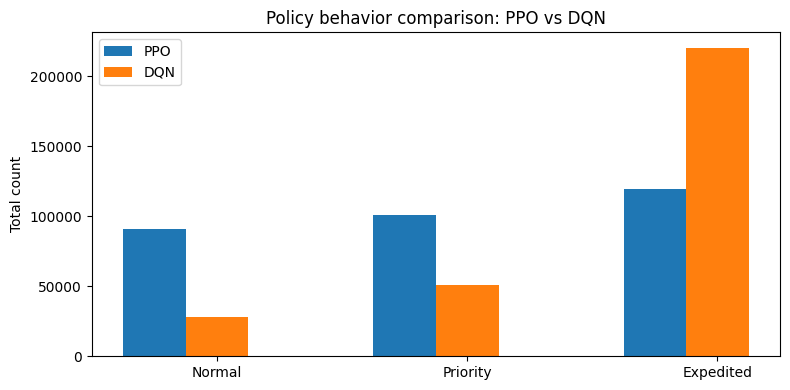

In [21]:
labels = ["Normal", "Priority", "Expedited"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 4))

plt.bar(
    x - width,
    [ppo_actions[l] for l in labels],
    width,
    label="PPO"
)

plt.bar(
    x,
    [dqn_actions[l] for l in labels],
    width,
    label="DQN"
)



plt.xticks(x, labels)
plt.ylabel("Total count")
plt.title("Policy behavior comparison: PPO vs DQN")
plt.legend()
plt.tight_layout()
plt.show()

